# Imports & Paths

In [ ]:
import json
import math
from pathlib import Path
 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
 
METRICS_FILE = Path("results//fl_metrics.json")
 
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
ACCENT   = "#4C72B0"   
ACCENT2  = "#DD8452"   
ACCENT3  = "#55A868"  
DANGER   = "#C44E52"  
GRID_CLR = "#e0e0e0"
 
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.framealpha": 0.85,
})

# JSON Loading

In [ ]:
with open(METRICS_FILE) as f:
    raw = json.load(f)
 
rounds = pd.DataFrame([
    {
        "round":               r["round_num"],
        "auroc_macro":         r["auroc_macro"],
        "f1_macro":            r["f1_macro"],
        "recall_macro":        r["recall_macro"],
        "precision_macro":     r["precision_macro"],
        "val_loss":            r["val_loss"],
        "mia_vulnerability":   r["mia_vulnerability"],
        "bandwidth_efficiency":r["bandwidth_efficiency"],
        "wall_time_s":         r["wall_time_s"],
        "aggregation_time_s":  r["aggregation_time_s"],
        "max_client_compute_s":r["max_client_compute_s"],
        "total_upload_mb":     r["total_upload_mb"],
        "total_download_mb":   r["total_download_mb"],
        "ood_auroc_macro":     r.get("ood_auroc_macro", float("nan")),
        "ood_f1_macro":        r.get("ood_f1_macro",    float("nan")),
    }
    for r in raw
])
 
client_rows = []
for r in raw:
    for c in r.get("client_stats", []):
        client_rows.append({
            "round":          c["round_num"],
            "client_id":      c["client_id"],
            "compute_time_s": c["compute_time_s"],
            "upload_mb":      c["upload_bytes"]   / 1e6,
            "download_mb":    c["download_bytes"]  / 1e6,
            "train_loss":     c["train_loss"],
            "num_examples":   c["num_examples"],
        })
clients = pd.DataFrame(client_rows)
 
# Derived
rounds["total_comm_mb"] = rounds["total_upload_mb"] + rounds["total_download_mb"]
rounds["cumulative_comm_mb"] = rounds["total_comm_mb"].cumsum()
rounds["wait_time_s"] = (rounds["wall_time_s"]
                         - rounds["max_client_compute_s"]
                         - rounds["aggregation_time_s"]).clip(lower=0)
 
print(f"Loaded {len(rounds)} rounds, {len(clients)} client records.")
print(f"Clients seen: {sorted(clients['client_id'].unique())}")
rounds.head()

Loaded 28 rounds, 84 client records.
Clients seen: ['343574.0', '565387.0', '776918.0']


,round,auroc_macro,f1_macro,recall_macro,precision_macro,val_loss,mia_vulnerability,bandwidth_efficiency,wall_time_s,aggregation_time_s,max_client_compute_s,total_upload_mb,total_download_mb,ood_auroc_macro,ood_f1_macro,total_comm_mb,cumulative_comm_mb,wait_time_s
0,1,0.667932,0.097907,0.086793,0.213474,0.093869,0.562500,0.003676,91.252753,0.0,908.617730,90.861504,90.861504,NaN,NaN,181.723008,181.723008,0.0
1,2,0.714776,0.102979,0.109548,0.182956,0.091850,0.560547,0.000258,88.719963,0.0,478.639206,90.861504,90.861504,NaN,NaN,181.723008,363.446016,0.0
2,3,0.742896,0.132764,0.136352,0.196521,0.088687,0.566406,0.000155,92.121411,0.0,888.111963,90.861504,90.861504,NaN,NaN,181.723008,545.169024,0.0
3,4,0.752517,0.153058,0.148774,0.242868,0.088379,0.564453,0.000053,88.937689,0.0,975.609179,90.861504,90.861504,NaN,NaN,181.723008,726.892032,0.0
4,5,0.767242,0.183395,0.175758,0.279464,0.087038,0.562500,0.000081,93.013071,0.0,810.282180,90.861504,90.861504,NaN,NaN,181.723008,908.615040,0.0


# Model Quality

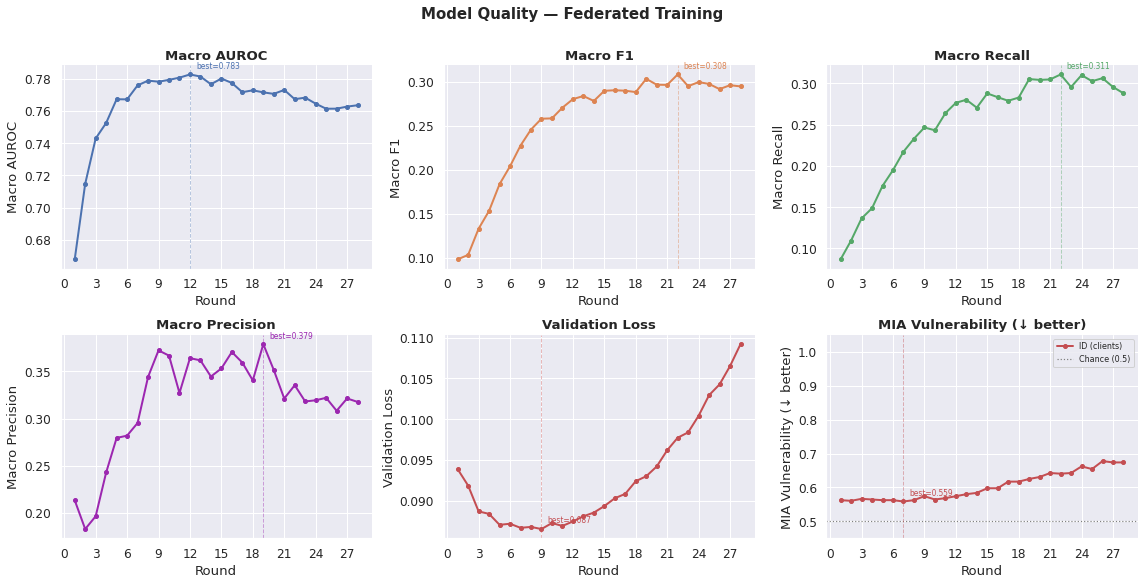

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Model Quality — Federated Training", fontsize=15, fontweight="bold", y=1.01)
 
metric_cfg = [
    ("auroc_macro",     "Macro AUROC",     ACCENT,  "ood_auroc_macro"),
    ("f1_macro",        "Macro F1",        ACCENT2, "ood_f1_macro"),
    ("recall_macro",    "Macro Recall",    ACCENT3, None),
    ("precision_macro", "Macro Precision", "#9C27B0", None),
    ("val_loss",        "Validation Loss", DANGER,  None),
    ("mia_vulnerability","MIA Vulnerability (↓ better)", DANGER, None),
]
 
x = rounds["round"]
 
for ax, (col, title, color, ood_col) in zip(axes.flat, metric_cfg):
    y = rounds[col]
    ax.plot(x, y, color=color, linewidth=2, marker="o", markersize=4, label="ID (clients)")
 
    if ood_col and ood_col in rounds.columns:
        y_ood = rounds[ood_col]
        if y_ood.notna().any():
            ax.plot(x, y_ood, color=color, linewidth=1.5, linestyle="--",
                    marker="s", markersize=3, alpha=0.7, label="OOD (hospital_d)")
            ax.legend(fontsize=8)
 
    if col == "mia_vulnerability":
        ax.axhline(0.5, color="grey", linestyle=":", linewidth=1.2, label="Chance (0.5)")
        ax.set_ylim(0.45, 1.05)
        ax.legend(fontsize=8)
 
    if col != "val_loss" and col != "mia_vulnerability":
        best_idx = y.idxmax()
    else:
        best_idx = y.idxmin()
    ax.axvline(x[best_idx], color=color, linestyle="--", alpha=0.4, linewidth=1)
    ax.annotate(
        f"best={y[best_idx]:.3f}",
        xy=(x[best_idx], y[best_idx]),
        xytext=(6, 6), textcoords="offset points",
        fontsize=7.5, color=color,
    )
 
    ax.set_title(title, fontweight="semibold")
    ax.set_xlabel("Round")
    ax.set_ylabel(title)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
plt.tight_layout()
plt.show()

# Communication Overhead

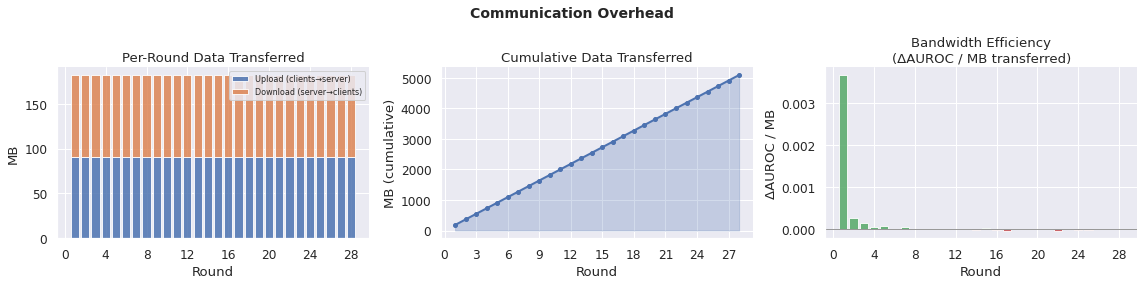

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Communication Overhead", fontsize=14, fontweight="bold")
 
x = rounds["round"]
 
ax = axes[0]
ax.bar(x, rounds["total_upload_mb"],   label="Upload (clients→server)", color=ACCENT,  alpha=0.85)
ax.bar(x, rounds["total_download_mb"], label="Download (server→clients)", color=ACCENT2,
       bottom=rounds["total_upload_mb"], alpha=0.85)
ax.set_title("Per-Round Data Transferred")
ax.set_xlabel("Round"); ax.set_ylabel("MB")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
ax = axes[1]
ax.fill_between(x, rounds["cumulative_comm_mb"], alpha=0.25, color=ACCENT)
ax.plot(x, rounds["cumulative_comm_mb"], color=ACCENT, linewidth=2, marker="o", markersize=4)
ax.set_title("Cumulative Data Transferred")
ax.set_xlabel("Round"); ax.set_ylabel("MB (cumulative)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
ax = axes[2]
eff = rounds["bandwidth_efficiency"].replace([np.inf, -np.inf], np.nan)
colors = [ACCENT3 if v >= 0 else DANGER for v in eff.fillna(0)]
ax.bar(x, eff, color=colors, alpha=0.85)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Bandwidth Efficiency\n(ΔAUROC / MB transferred)")
ax.set_xlabel("Round"); ax.set_ylabel("ΔAUROC / MB")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
plt.tight_layout()
plt.show()

# Temporal Overhead

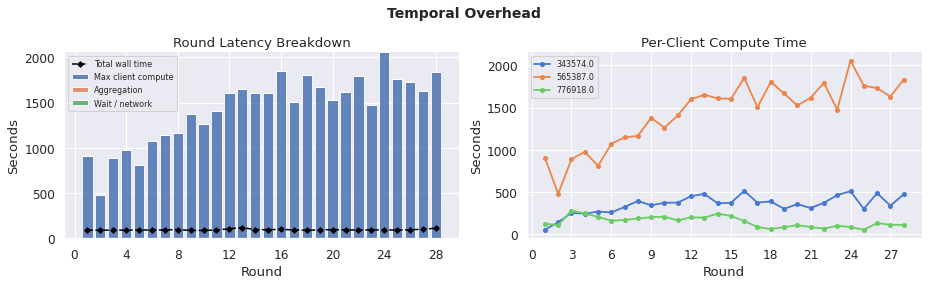

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Temporal Overhead", fontsize=14, fontweight="bold")
 
x = rounds["round"]
 
ax = axes[0]
ax.bar(x, rounds["max_client_compute_s"], label="Max client compute",  color=ACCENT,  alpha=0.85)
ax.bar(x, rounds["aggregation_time_s"],   label="Aggregation",         color=ACCENT2,
       bottom=rounds["max_client_compute_s"], alpha=0.85)
ax.bar(x, rounds["wait_time_s"],          label="Wait / network",      color=ACCENT3,
       bottom=rounds["max_client_compute_s"] + rounds["aggregation_time_s"], alpha=0.85)
ax.plot(x, rounds["wall_time_s"], color="black", linewidth=1.5,
        linestyle="--", marker="D", markersize=4, label="Total wall time")
ax.set_title("Round Latency Breakdown")
ax.set_xlabel("Round"); ax.set_ylabel("Seconds")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
ax = axes[1]
if not clients.empty:
    for cid, grp in clients.groupby("client_id"):
        ax.plot(grp["round"], grp["compute_time_s"],
                marker="o", markersize=4, linewidth=1.8, label=cid)
    ax.set_title("Per-Client Compute Time")
    ax.set_xlabel("Round"); ax.set_ylabel("Seconds")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
else:
    ax.text(0.5, 0.5, "No client-level data", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="grey")
 
plt.tight_layout()
plt.show()

# Client Statistics

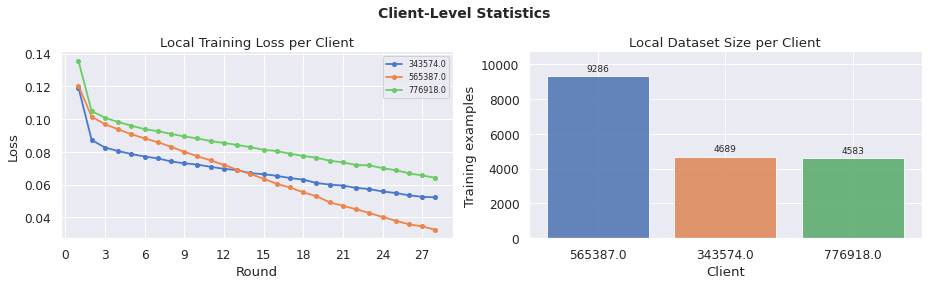

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Client-Level Statistics", fontsize=14, fontweight="bold")
 
ax = axes[0]
if not clients.empty:
    for cid, grp in clients.groupby("client_id"):
        ax.plot(grp["round"], grp["train_loss"],
                marker="o", markersize=4, linewidth=1.8, label=cid)
    ax.set_title("Local Training Loss per Client")
    ax.set_xlabel("Round"); ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
ax = axes[1]
if not clients.empty:
    sizes = clients.groupby("client_id")["num_examples"].first().sort_values(ascending=False)
    bars = ax.bar(sizes.index, sizes.values, color=[ACCENT, ACCENT2, ACCENT3][:len(sizes)], alpha=0.85)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
    ax.set_title("Local Dataset Size per Client")
    ax.set_xlabel("Client"); ax.set_ylabel("Training examples")
    ax.set_ylim(0, sizes.max() * 1.15)
 
plt.tight_layout()
plt.show()

# MIA

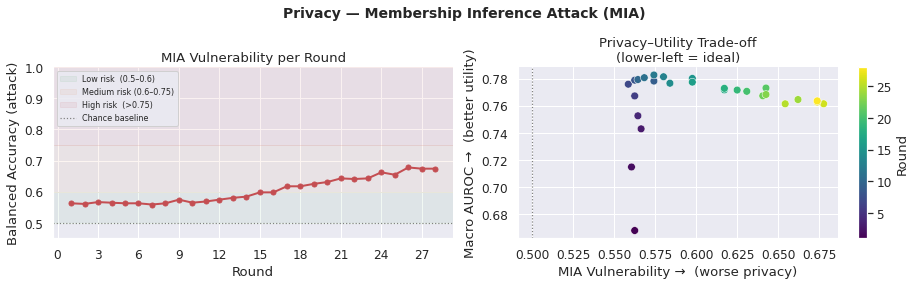

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Privacy — Membership Inference Attack (MIA)", fontsize=14, fontweight="bold")
 
x = rounds["round"]
mia = rounds["mia_vulnerability"]
 
ax = axes[0]
ax.axhspan(0.5,  0.6,  alpha=0.08, color=ACCENT3, label="Low risk  (0.5–0.6)")
ax.axhspan(0.6,  0.75, alpha=0.08, color=ACCENT2, label="Medium risk (0.6–0.75)")
ax.axhspan(0.75, 1.0,  alpha=0.08, color=DANGER,  label="High risk  (>0.75)")
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1.2, label="Chance baseline")
ax.plot(x, mia, color=DANGER, linewidth=2, marker="o", markersize=5, zorder=5)
ax.set_ylim(0.45, 1.0)
ax.set_title("MIA Vulnerability per Round")
ax.set_xlabel("Round"); ax.set_ylabel("Balanced Accuracy (attack)")
ax.legend(fontsize=8, loc="upper left")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
ax = axes[1]
valid = rounds.dropna(subset=["auroc_macro", "mia_vulnerability"])
sc = ax.scatter(
    valid["mia_vulnerability"], valid["auroc_macro"],
    c=valid["round"], cmap="viridis", s=60, zorder=5, edgecolors="white", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label="Round")
ax.axvline(0.5, color="grey", linestyle=":", linewidth=1.2)
ax.set_title("Privacy–Utility Trade-off\n(lower-left = ideal)")
ax.set_xlabel("MIA Vulnerability →  (worse privacy)")
ax.set_ylabel("Macro AUROC →  (better utility)")
 
plt.tight_layout()
plt.show()

# ID vs OOD gap

In [ ]:
ood_available = rounds["ood_auroc_macro"].notna().any()
 
if ood_available:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("In-Distribution vs OOD Generalisation", fontsize=14, fontweight="bold")
 
    x = rounds["round"]
 
    ax = axes[0]
    ax.plot(x, rounds["auroc_macro"],     color=ACCENT,  linewidth=2, marker="o", markersize=4, label="ID AUROC")
    ax.plot(x, rounds["ood_auroc_macro"], color=ACCENT2, linewidth=2, marker="s", markersize=4,
            linestyle="--", label="OOD AUROC")
    ax.fill_between(x, rounds["ood_auroc_macro"], rounds["auroc_macro"],
                    alpha=0.12, color=DANGER, label="Generalisation gap")
    ax.set_title("AUROC: ID vs OOD")
    ax.set_xlabel("Round"); ax.set_ylabel("Macro AUROC")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
    ax = axes[1]
    ax.plot(x, rounds["f1_macro"],     color=ACCENT,  linewidth=2, marker="o", markersize=4, label="ID F1")
    ax.plot(x, rounds["ood_f1_macro"], color=ACCENT2, linewidth=2, marker="s", markersize=4,
            linestyle="--", label="OOD F1")
    ax.fill_between(x, rounds["ood_f1_macro"], rounds["f1_macro"],
                    alpha=0.12, color=DANGER, label="Generalisation gap")
    ax.set_title("F1: ID vs OOD")
    ax.set_xlabel("Round"); ax.set_ylabel("Macro F1")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
    plt.tight_layout()
    plt.show()
else:
    print("OOD metrics not present in this log file — skipping Figure 6.")
    print("This is expected if hospital_d was unavailable during training.")

OOD metrics not present in this log file — skipping Figure 6.
This is expected if hospital_d was unavailable during training.


# Summary Table

In [ ]:
def _fmt(val, decimals=4):
    return f"{val:.{decimals}f}" if not math.isnan(val) else "—"
 
best_auroc_round = rounds.loc[rounds["auroc_macro"].idxmax()]
final_round      = rounds.iloc[-1]
 
summary = pd.DataFrame({
    "Metric": [
        "Final AUROC (macro)",
        "Final F1 (macro)",
        "Final Recall (macro)",
        "Final Precision (macro)",
        "Final Val Loss",
        "Final MIA Vulnerability",
        "Best AUROC (round)",
        "Best AUROC value",
        "Total rounds",
        "Total communication (MB)",
        "Avg wall time / round (s)",
        "Avg client compute / round (s)",
    ],
    "Value": [
        _fmt(final_round["auroc_macro"]),
        _fmt(final_round["f1_macro"]),
        _fmt(final_round["recall_macro"]),
        _fmt(final_round["precision_macro"]),
        _fmt(final_round["val_loss"]),
        _fmt(final_round["mia_vulnerability"]),
        str(int(best_auroc_round["round"])),
        _fmt(best_auroc_round["auroc_macro"]),
        str(len(rounds)),
        _fmt(rounds["total_comm_mb"].sum(), 2),
        _fmt(rounds["wall_time_s"].mean(), 1),
        _fmt(rounds["max_client_compute_s"].mean(), 1),
    ],
})
 
display(summary.style
    .set_caption("Federated Training — Summary")
    .set_properties(**{"text-align": "left"})
    .hide(axis="index")
)

Metric,Value
Final AUROC (macro),0.7635
Final F1 (macro),0.2945
Final Recall (macro),0.2880
Final Precision (macro),0.3176
Final Val Loss,0.1092
Final MIA Vulnerability,0.6738
Best AUROC (round),12
Best AUROC value,0.7826
Total rounds,28
Total communication (MB),5088.24
